In [1]:
# import library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# load dataset 
df_market = pd.read_csv('marketing_campaign_performance_10000.csv')
df_market

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86
...,...,...,...,...,...,...,...,...,...,...,...
9995,CAMP09996,2025-05-28,2025-06-03,Influencer,112030,1896,627,152,4491.36,12415.83,1.76
9996,CAMP09997,2025-12-31,2026-01-06,Search,177412,11529,2021,955,761.85,1214.01,0.59
9997,CAMP09998,2025-12-30,2026-01-07,Social,41892,4098,940,470,116.84,339.12,1.90
9998,CAMP09999,2025-05-20,2025-05-28,Social,141674,10697,1834,385,2885.00,6580.54,1.28


In [3]:
df_market.info()        # Startdate dan EndDate belom menjadi datetime type nya jadi harus diubah dulu

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  str    
 1   StartDate    10000 non-null  str    
 2   EndDate      10000 non-null  str    
 3   Channel      10000 non-null  str    
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 859.5 KB


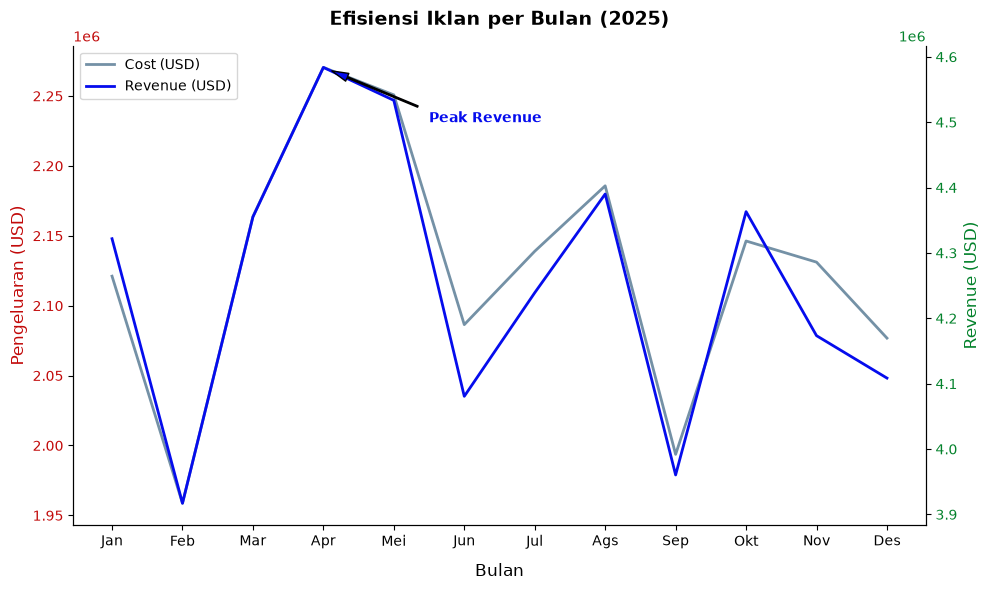

In [4]:
# 1. PENGOLAHAN DATA (Pandas)
# Membaca data & menangani konversi datetime dengan aman
df = pd.read_csv('marketing_campaign_performance_10000.csv')
df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')

# Ekstrak angka bulan sebagai jangkar (anchor) analisis bulanan
df['Month'] = df['StartDate'].dt.month

# Agregasi total biaya dan pendapatan berdasarkan bulan
biaya_bulan = df.groupby('Month')['Cost_USD'].sum()
pendapatan_bulan = df.groupby('Month')['Revenue_USD'].sum()


# 2. VISUALISASI (Matplotlib)
# Membuat 1 kanvas dan 1 bingkai grafik utama menggunakan bentuk jamak (subplots)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Garis Pertama: Cost (Sumbu Y Kiri)
ax1.plot(biaya_bulan.index, biaya_bulan.values, color='#7491a6', label='Cost (USD)', linewidth=2)
ax1.set_xlabel("Bulan", fontsize=12, labelpad=10)
ax1.set_ylabel("Pengeluaran (USD)", color='#c20a0a', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#c20a0a')

# Plot Garis Kedua: Revenue (Menciptakan sumbu Y Kanan dengan twinx)
ax2 = ax1.twinx()
ax2.plot(pendapatan_bulan.index, pendapatan_bulan.values, color='#050ced', label='Revenue (USD)', linewidth=2)
ax2.set_ylabel('Revenue (USD)', color='#04822c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#04822c')

# Mengubah indikator angka sumbu X menjadi Nama Bulan asli
ax1.set_xticks(biaya_bulan.index)
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des'])

# Memberikan judul formal laporan
ax1.set_title('Efisiensi Iklan per Bulan (2025)', fontsize=14, fontweight='bold', pad=15)

# Solusi Poin 1: Menjemput dan menggabungkan legenda dari dua lapisan sumbu Y
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Solusi Poin 2: Clean the Spines (Menghapus garis kaku bagian atas pada kedua sumbu)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Solusi Poin 4: Menambahkan panah anotasi pada titik puncak performa (Bulan April / 4)
ax2.annotate('Peak Revenue', 
             xy=(4, pendapatan_bulan[4]), 
             xytext=(5.5, 4500000),
             arrowprops=dict(facecolor='#050ced', shrink=0.08, width=1, headwidth=6),
             color='#050ced', fontweight='bold')

# Mengatur tata letak agar presisi dan tidak terpotong
plt.tight_layout()

# Menampilkan hasil visualisasi akhir
plt.show()